In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\mrabe\OneDrive\Documentos\Premier League Analysis\Data\matches_limpio.csv")
df['Date'] = pd.to_datetime(df['Date'])
print(f"Dataset cargado: {df.shape[0]} partidos ✓")

Dataset cargado: 12026 partidos ✓


In [5]:
tabla = pd.read_csv(r"C:\Users\mrabe\OneDrive\Documentos\Premier League Analysis\Data\tabla_posiciones_2023.csv", index_col=0)
print("Tabla de posiciones cargada ✓")

Tabla de posiciones cargada ✓


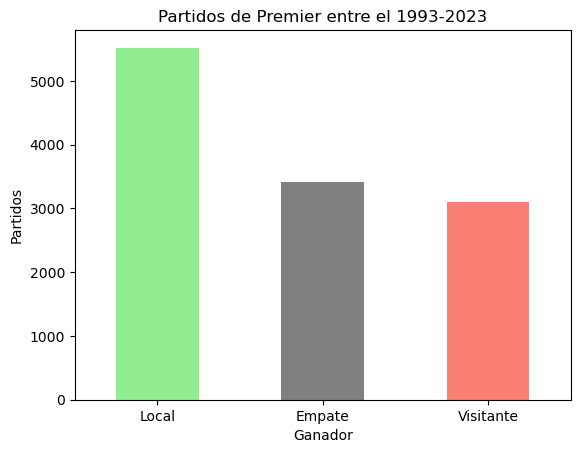

In [78]:
resultados = df['FTR'].value_counts()
resultados.index = ['Local', 'Empate', 'Visitante']
resultados.plot(kind = 'bar', color=['lightgreen', 'grey', 'salmon']) 
plt.title('Partidos de Premier entre el 1993-2023')
plt.xlabel('Ganador')
plt.ylabel('Partidos')
plt.xticks(rotation=0)
plt.show()

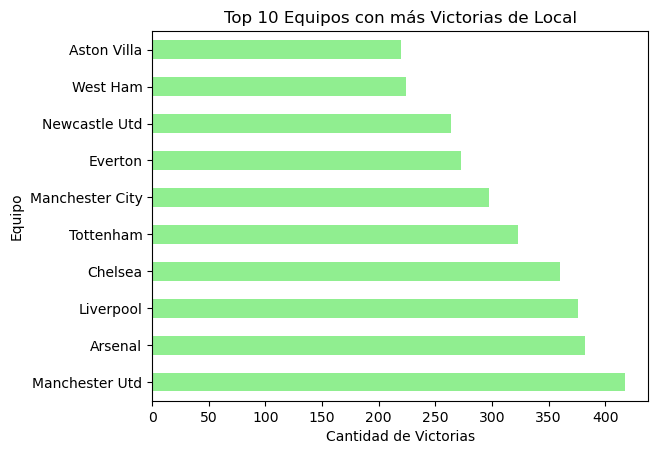

In [77]:
locales = df[df['FTR'] == 'H']['Home'].value_counts().head(10)
locales.plot(kind = 'barh', color = 'lightgreen')
plt.title('Top 10 Equipos con más Victorias de Local')
plt.xlabel('Cantidad de Victorias')
plt.ylabel('Equipo')
plt.show()

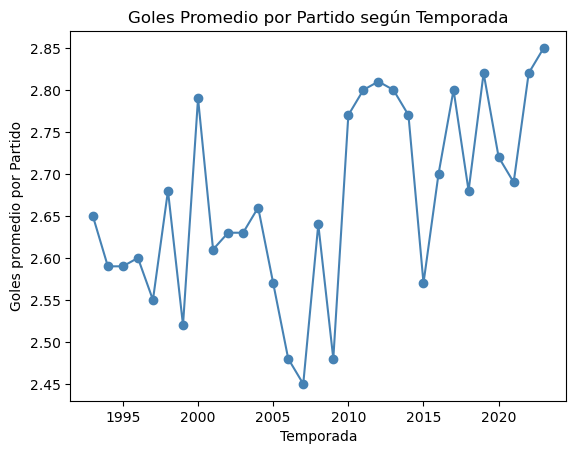

In [24]:
goles_temporada = df.groupby('Season_End_Year')['TotalGoals'].mean().round(2)
goles_temporada.plot(kind = 'line', color = 'steelblue', marker = 'o')
plt.title('Goles Promedio por Partido según Temporada')
plt.xlabel('Temporada')
plt.ylabel('Goles promedio por Partido')
plt.show()

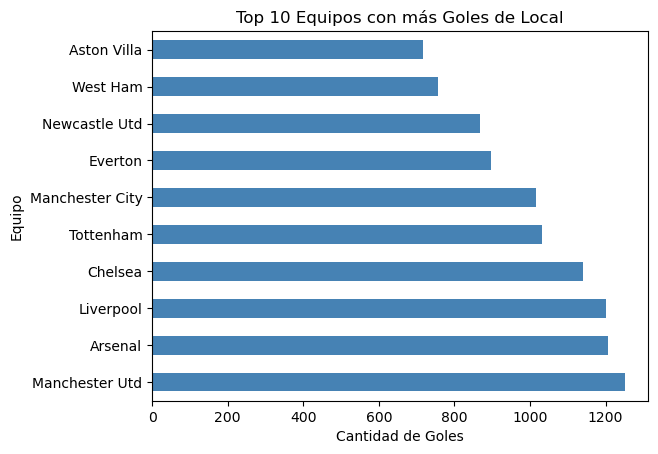

In [75]:
goles_local = df.groupby('Home')['HomeGoals'].sum().sort_values(ascending = False).head(10)
goles_local.plot(kind = 'barh', color = 'steelblue')
plt.title('Top 10 Equipos con más Goles de Local')
plt.xlabel('Cantidad de Goles')
plt.ylabel('Equipo')
plt.show()

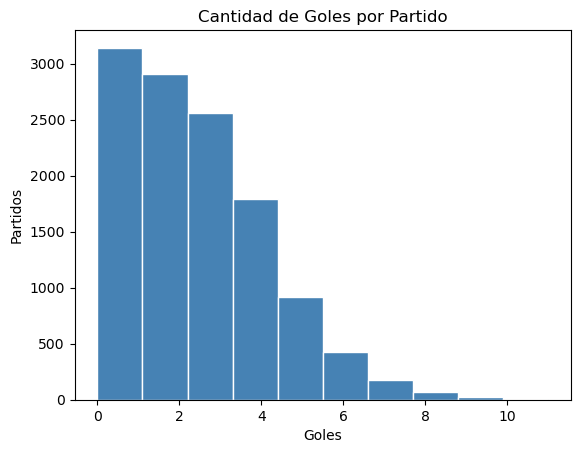

In [76]:
df['TotalGoals'].plot(kind = 'hist', bins = 10, color = 'steelblue', edgecolor = 'white')
plt.title('Cantidad de Goles por Partido')
plt.xlabel('Goles')
plt.ylabel('Partidos')
plt.show()

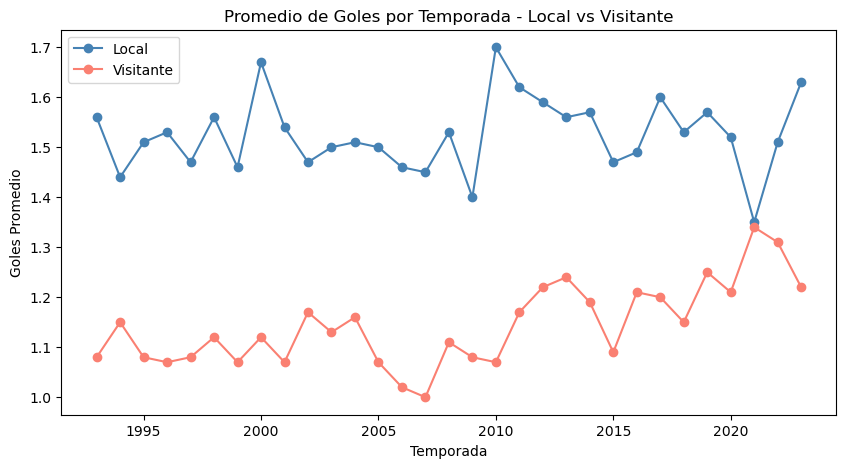

In [57]:
goles_local = df.groupby('Season_End_Year')['HomeGoals'].mean().round(2)
goles_visitante = df.groupby('Season_End_Year')['AwayGoals'].mean().round(2)

plt.figure(figsize=(10, 5))
plt.plot(goles_local, color='steelblue', marker='o', label='Local')
plt.plot(goles_visitante, color='salmon', marker='o', label='Visitante')

plt.title('Promedio de Goles por Temporada - Local vs Visitante')
plt.xlabel('Temporada')
plt.ylabel('Goles Promedio')
plt.legend()
plt.show()

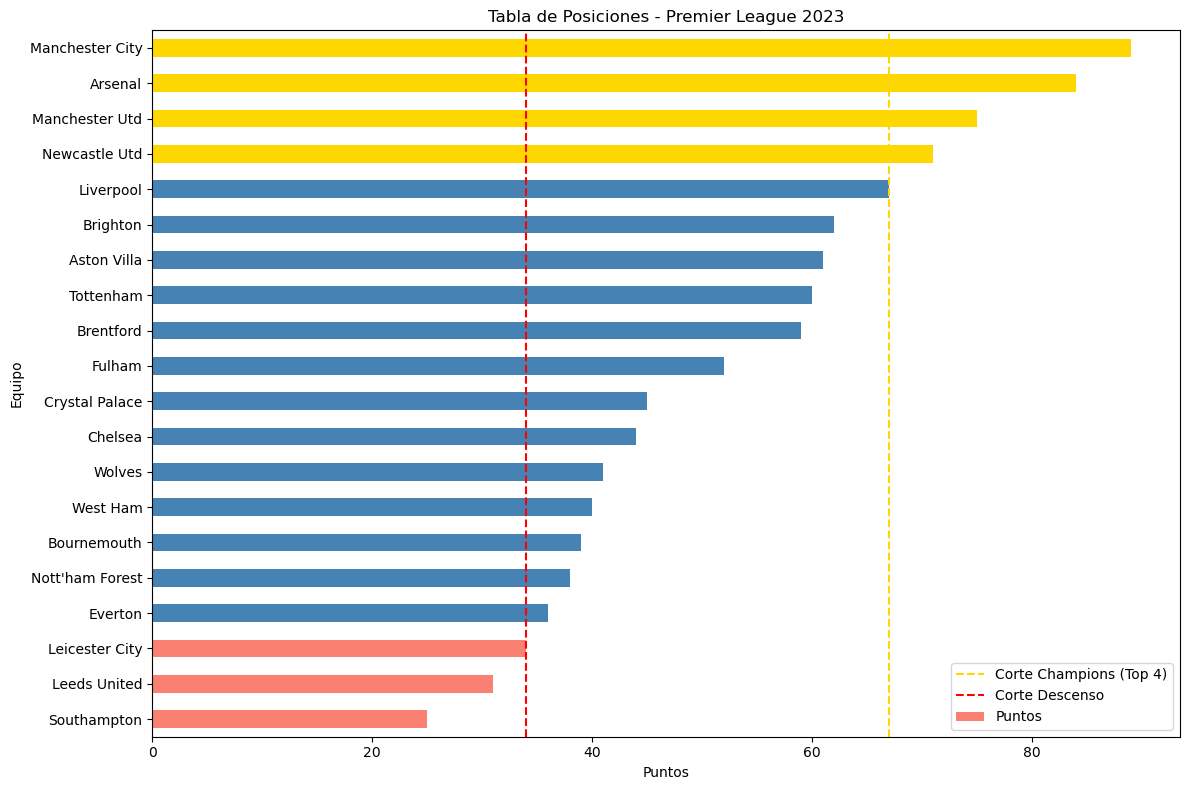

In [6]:
plt.figure(figsize=(12, 8))

colores = ['gold' if i <= 3 else 'salmon' if i >= 17 else 'steelblue' for i in range(len(tabla))]

tabla_ordenada = tabla.sort_values('Puntos', ascending=True)
colores_ordenados = colores[::-1]

tabla_ordenada.set_index('Equipo')['Puntos'].plot(kind='barh', color=colores_ordenados)

plt.title('Tabla de Posiciones - Premier League 2023')
plt.xlabel('Puntos')
plt.ylabel('Equipo')
plt.axvline(x=tabla.loc[5, 'Puntos'], color='gold', linestyle='--', linewidth=1.5, label='Corte Champions (Top 4)')
plt.axvline(x=tabla.loc[18, 'Puntos'], color='red', linestyle='--', linewidth=1.5, label='Corte Descenso')
plt.legend()
plt.tight_layout()
plt.show()

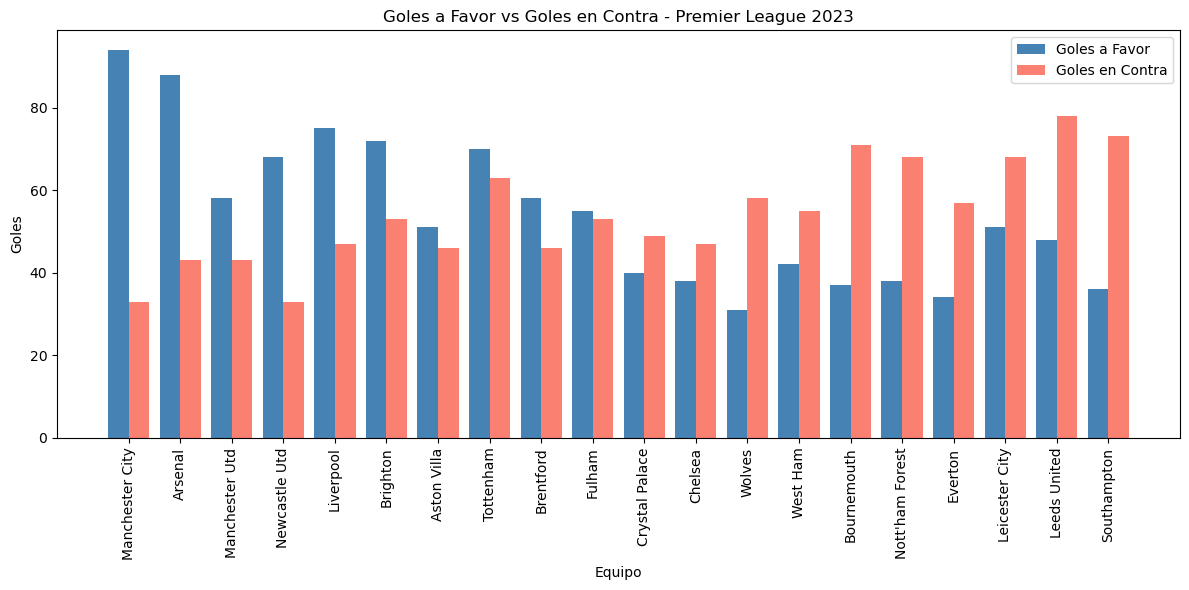

In [73]:
plt.figure(figsize=(12, 6))

x = range(len(tabla))
plt.bar(x, tabla['GolesAFavor'], width=0.4, align='center', color='steelblue', label='Goles a Favor')
plt.bar([i + 0.4 for i in x], tabla['GolesEnContra'], width=0.4, align='center', color='salmon', label='Goles en Contra')

plt.xticks([i + 0.2 for i in x], tabla['Equipo'], rotation=90)
plt.title('Goles a Favor vs Goles en Contra - Premier League 2023')
plt.xlabel('Equipo')
plt.ylabel('Goles')
plt.legend()
plt.tight_layout()
plt.show()

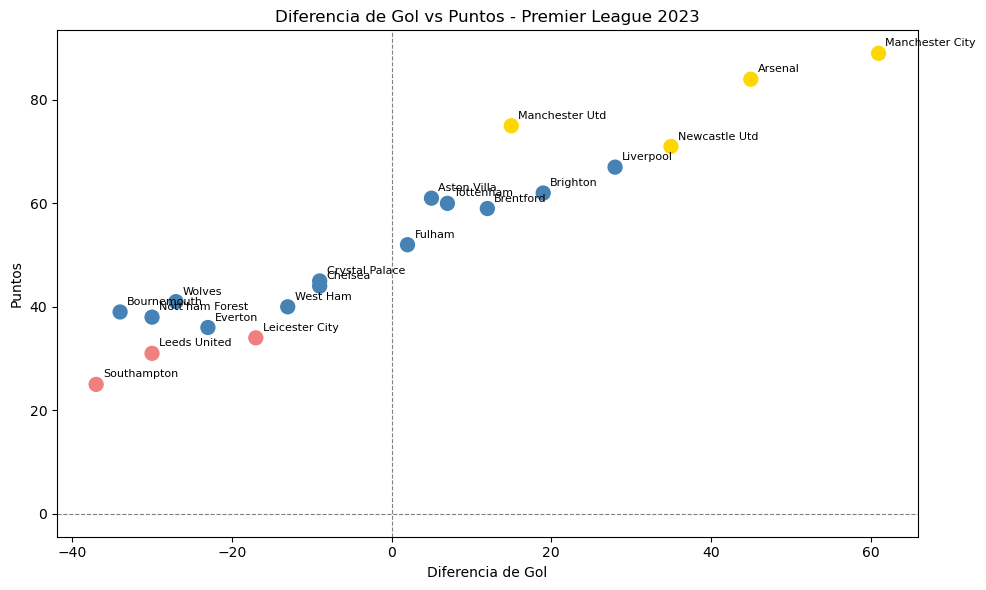

In [74]:
plt.figure(figsize=(10, 6))

colores = ['gold' if i <= 4 else 'lightcoral' if i >= 18 else 'steelblue' for i in tabla.index]

plt.scatter(tabla['DiferenciaGoles'], tabla['Puntos'], color=colores, s=100, zorder=3)

for i, row in tabla.iterrows():
    plt.annotate(row['Equipo'], (row['DiferenciaGoles'], row['Puntos']),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Diferencia de Gol vs Puntos - Premier League 2023')
plt.xlabel('Diferencia de Gol')
plt.ylabel('Puntos')
plt.tight_layout()
plt.show()